In [1]:
import numpy as np
import matplotlib.pyplot as plt

D = 0.9
nu_Sigma_f = 0.12

a = 200.0
N = 500
dx = a / (N + 1)
x_full = np.linspace(dx, a - dx, N)

# Spatially-varying absorption: baseline plus a localized "control rod" region
Sigma_a_base = 0.1
Sigma_a_bump = 0.15  # extra absorption in the rod region
rod_center = a / 2
rod_width = 20.0

Sigma_a = Sigma_a_base + Sigma_a_bump * (np.abs(x_full - rod_center) < rod_width / 2)

In [2]:
main_diag = 2.0 * D * np.ones(N) / dx**2
off_diag = -1.0 * D * np.ones(N-1) / dx**2
L = np.diag(main_diag) + np.diag(off_diag, k=1) + np.diag(off_diag, k=-1)

A_matrix = L + np.diag(Sigma_a)  # note: diag(Sigma_a), not Sigma_a * eye, since it now varies

In [3]:
M = A_matrix / nu_Sigma_f
eigenvalues, eigenvectors = np.linalg.eigh(M)

k_values = 1.0 / eigenvalues
k_eff = np.max(k_values)
print(f"k_eff = {k_eff}")

k_eff = 1.187665629716105


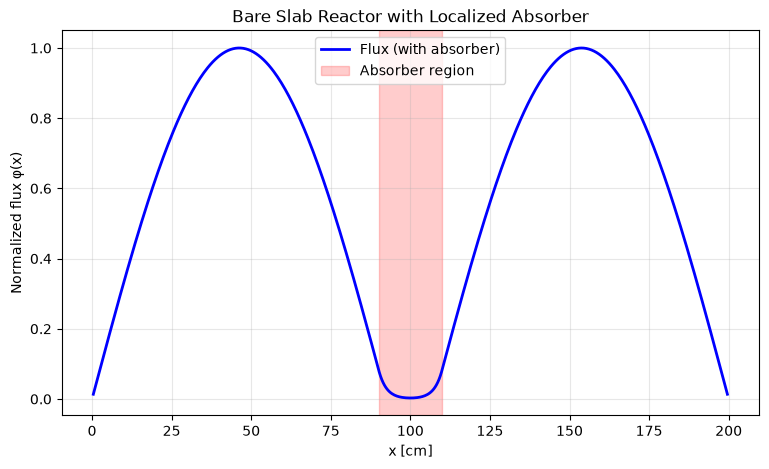

In [4]:
idx_fundamental = np.argmin(eigenvalues)
phi_num = eigenvectors[:, idx_fundamental]
phi_num = phi_num / np.max(np.abs(phi_num))

if phi_num[N//2] < 0:  # ensure positive convention, since eigh sign is arbitrary
    phi_num = -phi_num

plt.figure(figsize=(9, 5))
plt.plot(x_full, phi_num, 'b-', linewidth=2, label='Flux (with absorber)')
plt.axvspan(rod_center - rod_width/2, rod_center + rod_width/2, alpha=0.2, color='red', label='Absorber region')
plt.xlabel('x [cm]')
plt.ylabel('Normalized flux φ(x)')
plt.title('Bare Slab Reactor with Localized Absorber')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../assets/heterogeneous_flux_profile.png', dpi=150)
plt.show()

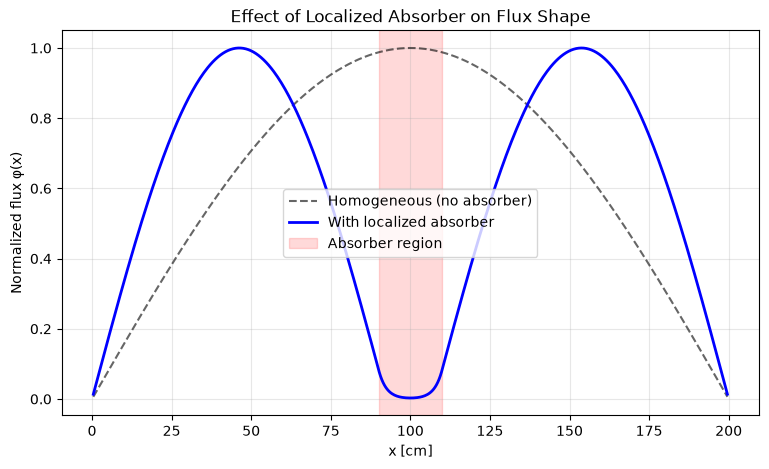

In [5]:
# Recompute homogeneous case for comparison (from notebook 01, same grid)
Sigma_a_homog = Sigma_a_base * np.ones(N)
A_homog = L + np.diag(Sigma_a_homog)
M_homog = A_homog / nu_Sigma_f
eigvals_homog, eigvecs_homog = np.linalg.eigh(M_homog)
idx_homog = np.argmin(eigvals_homog)
phi_homog = eigvecs_homog[:, idx_homog]
phi_homog = phi_homog / np.max(np.abs(phi_homog))
if phi_homog[N//2] < 0:
    phi_homog = -phi_homog

plt.figure(figsize=(9, 5))
plt.plot(x_full, phi_homog, 'k--', linewidth=1.5, label='Homogeneous (no absorber)', alpha=0.6)
plt.plot(x_full, phi_num, 'b-', linewidth=2, label='With localized absorber')
plt.axvspan(rod_center - rod_width/2, rod_center + rod_width/2, alpha=0.15, color='red', label='Absorber region')
plt.xlabel('x [cm]')
plt.ylabel('Normalized flux φ(x)')
plt.title('Effect of Localized Absorber on Flux Shape')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../assets/heterogeneous_vs_homogeneous_flux.png', dpi=150)
plt.show()

## Physical Interpretation

Introducing a localized absorber (representing a partially inserted control rod) reduces k_eff from 1.19734 (homogeneous case, notebook 01) to 1.18767 — consistent with the physical expectation that added absorption without added fissile material reduces reactivity.

The flux shape is strongly perturbed: rather than the smooth single-peak cosine profile of the homogeneous slab, the flux is depressed in the absorber region and redistributes into a two-peaked shape either side of it. This is the expected qualitative signature of control rod insertion in reactor physics.

No closed-form analytical solution exists for this heterogeneous case, since the absorption profile now varies spatially — the finite-difference operator is no longer tridiagonal Toeplitz. This mirrors the transition from the infinite square well to the harmonic oscillator in the companion `schrodinger-solver` repository: introducing spatial variation breaks the exact discrete-sine eigenvector property, and both eigenvalues and eigenvectors now carry genuine O(h²) discretization error rather than matching to machine precision.